In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('owid-covid-data.csv')



In [3]:
print("Columns in dataset:", df.columns)

Columns in dataset: Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'new_tests', 'total_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_

In [4]:
# Preview the first few rows
print("\nDataset preview:")
print(df.head())



Dataset preview:
  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-02-24          5.0        5.0   
1      AFG      Asia  Afghanistan  2020-02-25          5.0        0.0   
2      AFG      Asia  Afghanistan  2020-02-26          5.0        0.0   
3      AFG      Asia  Afghanistan  2020-02-27          5.0        0.0   
4      AFG      Asia  Afghanistan  2020-02-28          5.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           NaN         NaN                  NaN  ...   
1                 NaN           NaN         NaN                  NaN  ...   
2                 NaN           NaN         NaN                  NaN  ...   
3                 NaN           NaN         NaN                  NaN  ...   
4                 NaN           NaN         NaN                  NaN  ...   

   female_smokers  male_smokers  handwashing_facilities  \
0             NaN    

In [5]:
# Identify missing values in the dataset
print("\nMissing values count:")
print(df.isnull().sum())



Missing values count:
iso_code                                        0
continent                                    9956
location                                        0
date                                            0
total_cases                                  3033
                                            ...  
human_development_index                     30073
excess_mortality_cumulative_absolute       160630
excess_mortality_cumulative                160630
excess_mortality                           160630
excess_mortality_cumulative_per_million    160630
Length: 67, dtype: int64


In [6]:
# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

In [8]:
def filter_dataframe_by_countries(dataframe, countries):
    """
    Filter a DataFrame to include only rows where the 'location' column value
    is in the specified list of countries.
    
    Args:
        dataframe (pd.DataFrame): The DataFrame to filter
        countries (list): List of country names to include
        
    Returns:
        pd.DataFrame: Filtered DataFrame containing only the specified countries
    """
    return dataframe[dataframe['location'].isin(countries)]

# Define countries of interest
selected_countries = ['Kenya', 'United States', 'India']

# Apply the filter to the dataframe
df = filter_dataframe_by_countries(df, selected_countries)

In [9]:
# Drop rows where critical values (date, total_cases, total_deaths) are missing
df = df.dropna(subset=['date', 'total_cases', 'total_deaths'])


In [10]:
# Handle missing numeric values (fill with interpolation)
df.fillna(method='ffill', inplace=True)  # Forward-fill missing values
df.fillna(method='bfill', inplace=True)  # Back-fill as needed

In [11]:
# Display the cleaned dataset info
print("\nCleaned Dataset Info:")
print(df.info())


Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 2171 entries, 69719 to 157995
Data columns (total 67 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   iso_code                                    2171 non-null   object        
 1   continent                                   2171 non-null   object        
 2   location                                    2171 non-null   object        
 3   date                                        2171 non-null   datetime64[ns]
 4   total_cases                                 2171 non-null   float64       
 5   new_cases                                   2171 non-null   float64       
 6   new_cases_smoothed                          2171 non-null   float64       
 7   total_deaths                                2171 non-null   float64       
 8   new_deaths                                  2171 non-null   floa

In [12]:
# Preview cleaned data
print("\nCleaned Data Preview:")
print(df.head())


Cleaned Data Preview:
      iso_code continent location       date  total_cases  new_cases  \
69719      IND      Asia    India 2020-03-11         62.0        6.0   
69720      IND      Asia    India 2020-03-12         73.0       11.0   
69721      IND      Asia    India 2020-03-13         82.0        9.0   
69722      IND      Asia    India 2020-03-14        102.0       20.0   
69723      IND      Asia    India 2020-03-15        113.0       11.0   

       new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
69719               4.857           1.0         1.0                0.429  ...   
69720               6.143           1.0         0.0                0.429  ...   
69721               7.286           2.0         1.0                0.429  ...   
69722               9.714           2.0         0.0                0.429  ...   
69723              10.571           2.0         0.0                0.429  ...   

       female_smokers  male_smokers  handwashing_faciliti

# Assistant
Here's my refactored version of the selected code:


In [18]:
def plot_total_cases(countries: list, df: pd.DataFrame) -> None:
    """
    Plot the total COVID-19 cases over time for selected countries.
    
    Args:
        countries (list): List of country names to plot.
        df (pd.DataFrame): DataFrame containing COVID-19 data with columns 
                          'location', 'date', and 'total_cases'.
    
    Returns:
        None: Displays the plot.
    """
    plt.figure(figsize=(15, 8))
    
    for country in countries:
        country_data = df[df['location'] == country]
        plt.plot(country_data['date'], country_data['total_cases'], label=country)
    
    plt.title('Total COVID-19 Cases Over Time')
    plt.xlabel('Date')
    plt.ylabel('Total Cases')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_total_cases(countries: list, df: pd.DataFrame) -> None:
    """
    Plot the total COVID-19 cases over time for selected countries.
    
    Args:
        countries (list): List of country names to plot.
        df (pd.DataFrame): DataFrame containing COVID-19 data with columns 
                          'location', 'date', and 'total_cases'.
    
    Returns:
        None: Displays the plot.
    """
    plt.figure(figsize=(15, 8))
    
    for country in countries:
        country_data = df[df['location'] == country]
        plt.plot(country_data['date'], country_data['total_cases'], label=country)
    
    plt.title('Total COVID-19 Cases Over Time')
    plt.xlabel('Date')
    plt.ylabel('Total Cases')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [31]:
import numpy as np
import pandas as pd

def calculate_death_rate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate the death rate as a percentage for each row in the dataframe.

    Args:
        df (pd.DataFrame): DataFrame containing 'total_deaths' and 'total_cases' columns.

    Returns:
        pd.DataFrame: The input DataFrame with an additional 'death_rate' column.
    """
    # Check if required columns exist
    required_columns = {'total_deaths', 'total_cases'}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"Missing required columns: {required_columns - set(df.columns)}")

    # Create a copy to avoid modifying the original dataframe
    result_df = df.copy()

    # Convert columns to numeric, forcing non-convertible values to NaN
    result_df['total_deaths'] = pd.to_numeric(result_df['total_deaths'], errors='coerce')
    result_df['total_cases'] = pd.to_numeric(result_df['total_cases'], errors='coerce')

    # Replace zero values with NaN to avoid division by zero
    result_df['death_rate'] = (
        result_df['total_deaths'] / result_df['total_cases'].replace(0, np.nan) * 100
    )

    return result_df
    print(df.results_df)

# Example Usage:
df = pd.read_csv("owid-covid-data.csv")
df = calculate_death_rate(df)



Descriptive Statistics:
                                date   total_cases     new_cases  \
count                           2171  2.171000e+03  2.171000e+03   
mean   2021-03-08 14:07:01.188392448  1.500437e+07  5.644940e+04   
min              2020-02-29 00:00:00  2.500000e+01  0.000000e+00   
25%              2020-09-09 00:00:00  1.711550e+05  5.505000e+02   
50%              2021-03-09 00:00:00  5.794041e+06  2.034600e+04   
75%              2021-09-05 12:00:00  3.160882e+07  6.117900e+04   
max              2022-03-05 00:00:00  7.926573e+07  1.368167e+06   
std                              NaN  1.859620e+07  1.087396e+05   

       new_cases_smoothed   total_deaths   new_deaths  new_deaths_smoothed  \
count         2171.000000    2171.000000  2171.000000          2171.000000   
mean         56380.270121  230721.894058   678.912022           676.407314   
min              1.286000       1.000000     0.000000             0.000000   
25%            560.714500    3403.000000    11.000

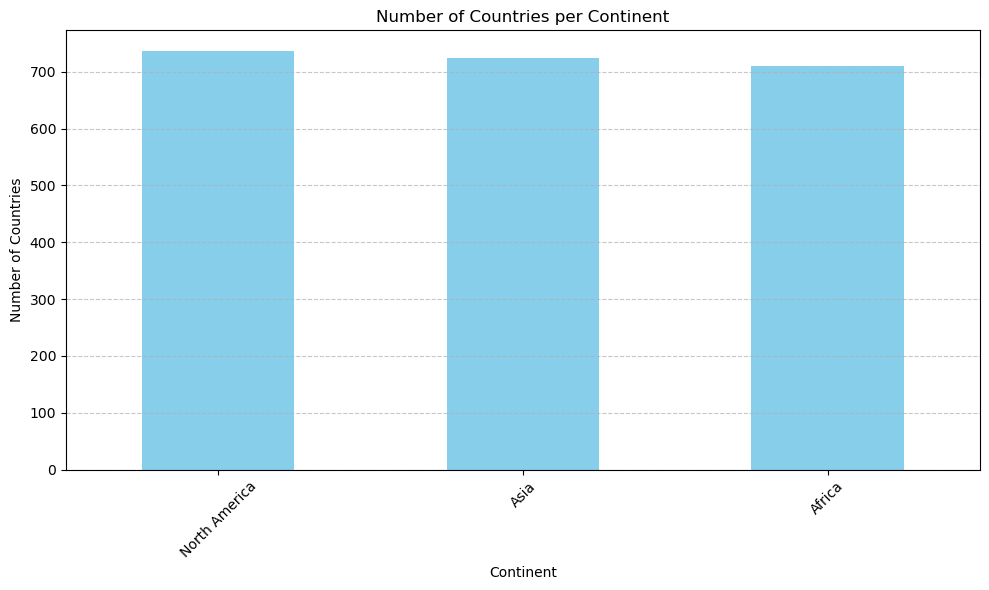

In [20]:
# Generate descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# Display the first few rows of the dataset
print("\nDataset Preview:")
print(df.head())

# #bar chart
df['continent'].value_counts().plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Number of Countries per Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Countries')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

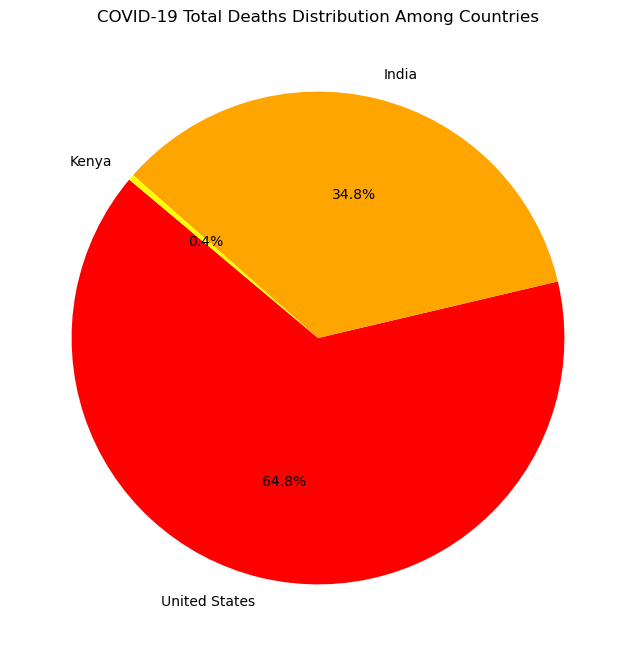

In [21]:

# Aggregate total deaths by country
deaths_by_country = df.groupby('location')['total_deaths'].max()

# Select top countries for visualization (adjust as needed)
top_countries = deaths_by_country.nlargest(5)  # Selects the top 5 countries with highest deaths

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%', startangle=140, colors=['red', 'orange', 'yellow', 'purple', 'blue'])
plt.title('COVID-19 Total Deaths Distribution Among Countries')
plt.show()


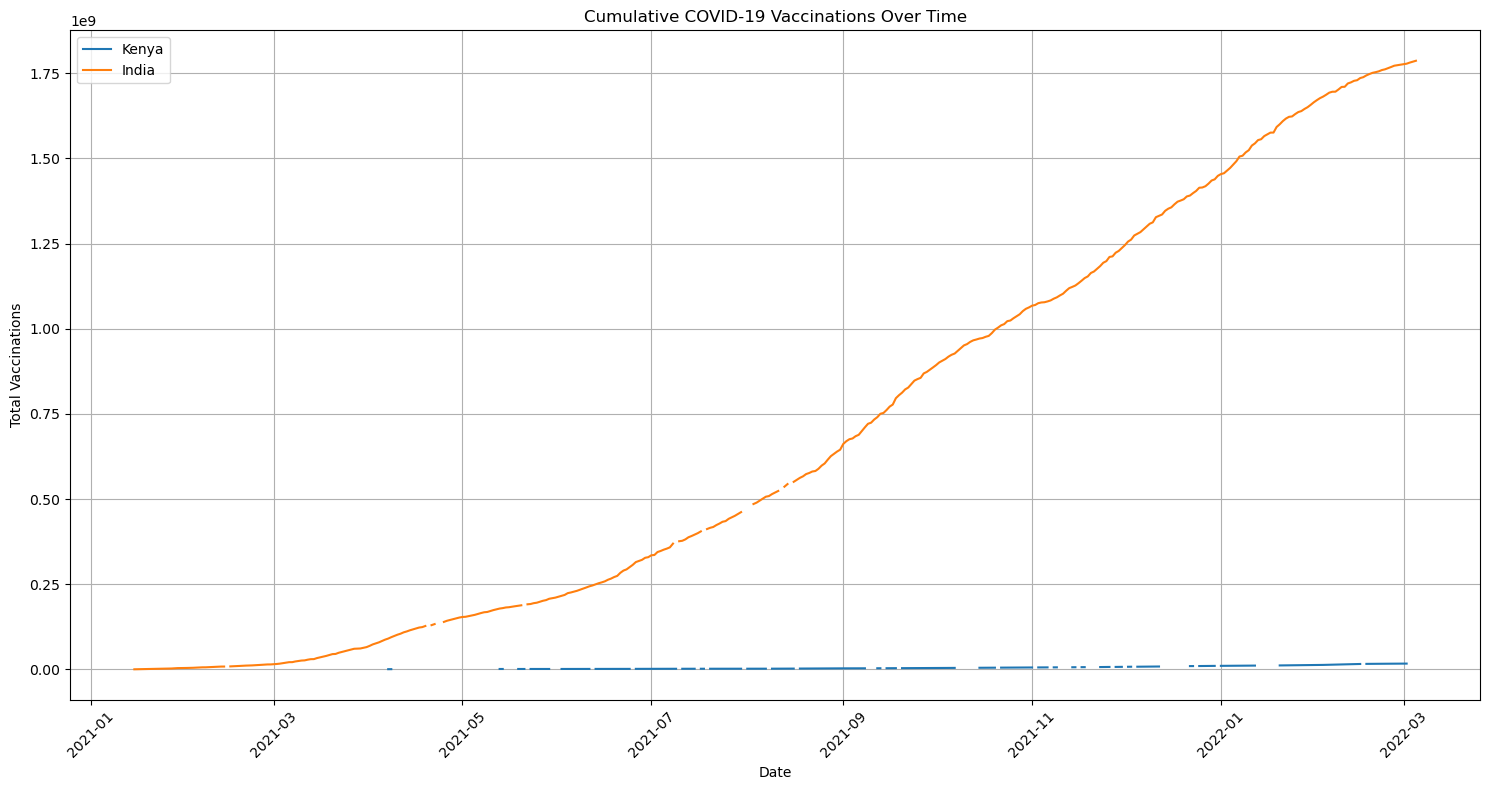

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_vaccination_trends(df, countries):
    # Ensure date column is in datetime format
    df['date'] = pd.to_datetime(df['date'])

    plt.figure(figsize=(15, 8))

    for country in countries:
        country_data = df[df['location'] == country]

        # Check if country exists in the dataset
        if country_data.empty:
            print(f"Warning: No data found for {country}")
            continue

        plt.plot(country_data['date'], country_data['total_vaccinations'], label=country)

    plt.title('Cumulative COVID-19 Vaccinations Over Time')
    plt.xlabel('Date')
    plt.ylabel('Total Vaccinations')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example Usage:
df = pd.read_csv("owid-covid-data.csv")  # Load your dataset
plot_vaccination_trends(df, ["Kenya", "USA", "India"])


In [2]:
import pandas as pd
import folium 

# Load the OWID dataset
df = pd.read_csv("owid-covid-data.csv")

# Select relevant columns and ensure correct data types
df_filtered = df[["location", "date", "total_deaths", "total_cases", "iso_code"]].dropna()

# Convert total cases and deaths to numeric values
df_filtered["total_cases"] = pd.to_numeric(df_filtered["total_cases"], errors="coerce")
df_filtered["total_deaths"] = pd.to_numeric(df_filtered["total_deaths"], errors="coerce")

# Calculate death rate percentage
df_filtered["death_rate"] = (df_filtered["total_deaths"] / df_filtered["total_cases"]) * 100

# Get the latest data for each country
latest_data = df_filtered.sort_values("date").groupby("location").last().reset_index()

# Load country coordinates (replace this with a proper mapping if necessary)
country_coords = {
    "Kenya": [1.2921, 36.8219],
    "USA": [37.0902, -95.7129],
    "India": [20.5937, 78.9629],
}

# Create a map centered around the world
m = folium.Map(location=[10, 0], zoom_start=2)

# Add circle markers for each country
for _, row in latest_data.iterrows():
    country = row["location"]
    if country in country_coords:
        folium.CircleMarker(
            location=country_coords[country],
            radius=8,
            color="red",
            fill=True,
            fill_color="red",
            fill_opacity=0.6,
            popup=f"{country}: {row['death_rate']:.2f}% death rate",
        ).add_to(m)


# Display the map (if in a Jupyter Notebook)
m

In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv("owid-covid-data.csv")

# Convert date column to datetime format
df["date"] = pd.to_datetime(df["date"])

# Filter only the latest data per country
latest_data = df.sort_values("date").groupby("location").last().reset_index()

# Calculate Death Rate (%)
latest_data["death_rate"] = (latest_data["total_deaths"] / latest_data["total_cases"]) * 100

# Select relevant columns
map_data = latest_data[["location", "iso_code", "death_rate", "population"]].copy()  # Ensure it's a copy

# Define country coordinates
country_coords = {
    "Kenya": [1.2921, 36.8219],
    "USA": [37.0902, -95.7129],
    "India": [20.5937, 78.9629],
    "Brazil": [-14.2350, -51.9253],
    "UK": [55.3781, -3.4360],
}

# Safely assign latitude and longitude using .loc[:, "column_name"]
map_data.loc[:, "latitude"] = map_data["location"].map(lambda x: country_coords.get(x, [None, None])[0])
map_data.loc[:, "longitude"] = map_data["location"].map(lambda x: country_coords.get(x, [None, None])[1])

# Drop rows with missing coordinates safely
map_data = map_data.dropna(subset=["latitude", "longitude"], how="any")

# Display final DataFrame to confirm
print(map_data.head())


    location iso_code  death_rate    population  latitude  longitude
29    Brazil      BRA    2.245861  2.139934e+08  -14.2350   -51.9253
96     India      IND    1.198791  1.393409e+09   20.5937    78.9629
110    Kenya      KEN    1.745746  5.498570e+07    1.2921    36.8219


In [11]:
import folium

# Create a global map centered on Africa (adjust zoom as needed)
m = folium.Map(location=[0, 30], zoom_start=2)

# Add circle markers for each country
for _, row in map_data.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=8,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.6,
        popup=f"{row['location']}: {row['death_rate']:.2f}% death rate",
    ).add_to(m)

# Display in Jupyter
m
